In [ ]:
# Breast Cancer EDA & Baseline
**Dataset:** Breast Cancer Wisconsin (scikit-learn)  
**What this notebook shows:** data inspection, target balance, feature correlation, a simple Random Forest baseline, and evaluation.


In [1]:
# basic data + plotting + model imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# load into a pandas DataFrame (features + target)
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df['target'] = data.target  # 0 = malignant, 1 = benign
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Shape:", df.shape)
print("\nColumn count:", len(df.columns))
print("\nTarget names:", data.target_names)
print("\nMissing values per column (should be 0):\n", df.isna().sum().head())
# show descriptive stats for numeric columns
df.describe().T


Shape: (569, 31)

Column count: 31

Target names: ['malignant' 'benign']

Missing values per column (should be 0):
 mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


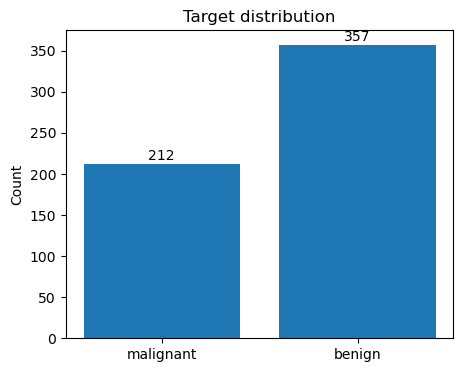

In [4]:
# plot class balance
plt.figure(figsize=(5,4))
counts = df['target'].value_counts().sort_index()
plt.bar([0,1], counts)
plt.xticks([0,1], data.target_names)
plt.title("Target distribution")
plt.ylabel("Count")
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()


Top positive correlations with target:
 smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
Name: target, dtype: float64

Top negative correlations with target:
 worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
Name: target, dtype: float64


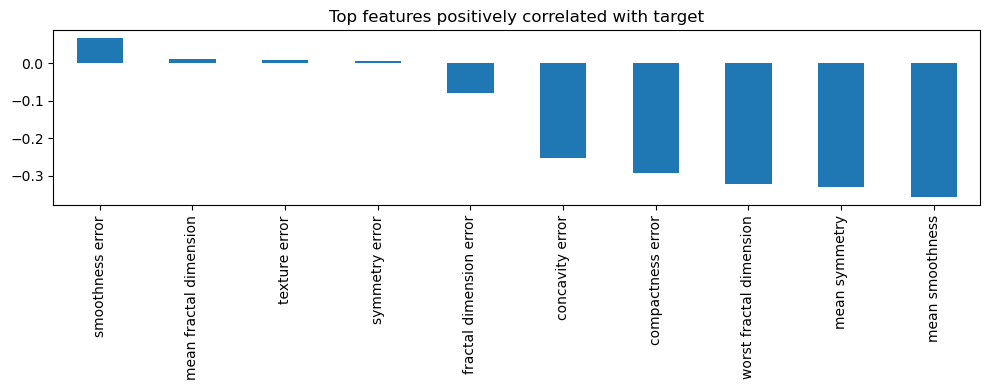

In [5]:
# compute correlations with target and show top positive/negative
corr_with_target = df.corr(numeric_only=True)['target'].drop('target')
top_pos = corr_with_target.sort_values(ascending=False).head(10)
top_neg = corr_with_target.sort_values().head(10)

print("Top positive correlations with target:\n", top_pos)
print("\nTop negative correlations with target:\n", top_neg)

plt.figure(figsize=(10,4))
top_pos.plot(kind='bar')
plt.title("Top features positively correlated with target")
plt.tight_layout()
plt.show()


In [6]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification report (test set):\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Classification report (test set):

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



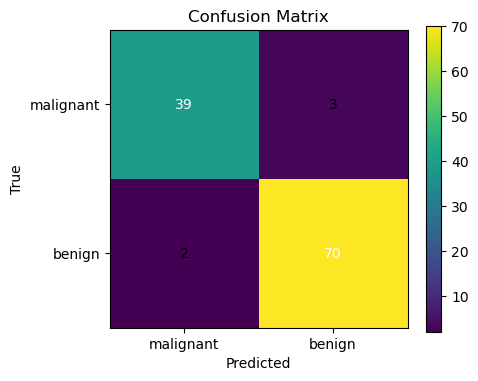

array([[39,  3],
       [ 2, 70]], dtype=int64)

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], data.target_names)
plt.yticks([0,1], data.target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()
cm


worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
mean perimeter          0.069574
mean radius             0.068676
mean concavity          0.057638
mean area               0.049172
worst concavity         0.034340
area error              0.033104
worst compactness       0.018600
worst texture           0.018597
radius error            0.016770
worst smoothness        0.012436
dtype: float64

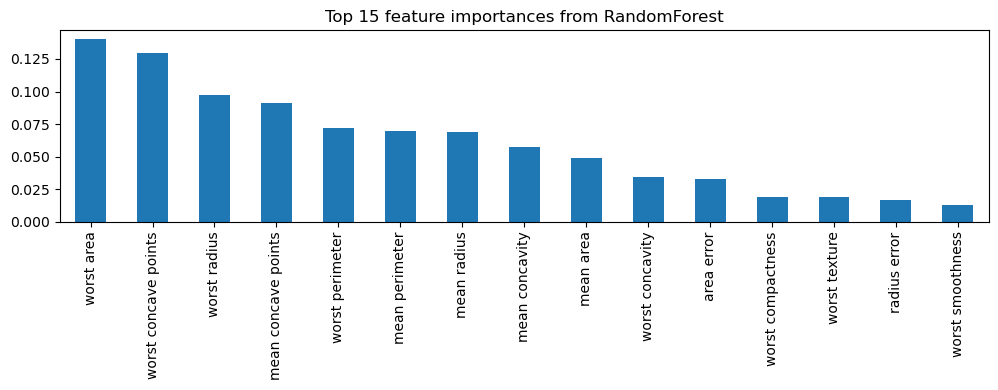

In [8]:
# show top features by RandomForest importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
display(importances.head(15))

plt.figure(figsize=(10,4))
importances.head(15).plot(kind='bar')
plt.title("Top 15 feature importances from RandomForest")
plt.tight_layout()
plt.show()


## Conclusions / Next steps
- The dataset is well-structured with no missing values.
- Random Forest baseline achieves strong classification metrics (see above).
- Next steps: try simple preprocessing, cross-validation, and a small hyperparameter search; or demonstrate a simple explainability method (SHAP/LIME) for top features.
